# Проект. Яндекс Афиша

- Автор: Королева Яна Тимофеевна
- Дата: 22.05.2026

### Введение

Сотрудники из отдела продукта в Яндекс Афише увидели изменения в продажах билетов. Необходимо разобраться в причинах изменений, выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

**Цель проекта** - Выявить причины изменений в пользвательском спросе, определить лидеров по событиям, площадкам и организаторам, а также сравнить активность пользователей мобильных устройств и стационарных компьютеров.

Для достижения поставленной цели необходимо выполнить **задачи**:
- Провести предобработку данных;
- Проанализировать распределение заказов по сегментам и их сезонные изменения;
- Проанализировать осеннюю активность пользователей;
- Выявить популярные события и партнёров;
- Провести статистический анализ данных;
- Сделать общий вывод и предложить рекомендации, на что стоит обратить внимание.

### Описание данных
**Датасет final_tickets_orders_df.csv** включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Датасет содержит поля:
- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия из таблицы events.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickets_count — количество купленных билетов.
- total — общая сумма заказа.
В данные также был добавлен столбец days_since_prev с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

**Датасет final_tickets_events_df** содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Обратите внимание, что из данных исключили фильмы, ведь, как было видно на дашборде, событий такого типа не так много. Датасет содержит такие поля:
- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки.

**Датасет final_tickets_tenge_df.csv** с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt).

# Шаг 1. Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [2]:
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
display(df_orders.info())
display(df_events.info())
display(df_tenge.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


None

In [4]:
display(df_orders.head(5))
display(df_events.head(5))
display(df_tenge.head(5))

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Датафрейм **orders** содержит  290849 строк и 14 столбцов. Данные соответствуют описанию. Названия столбцов понятны и информативны. В столбце 'days_since_prev' есть пропуски, но это является нормой, за счет описания столбца.  Столбцы 'created_dt_msk' и 'created_ts_msk' необходимо преобразовать в тип даты и времени. Столбец 'event_id' необходимо преобразовать в object.

Датафрейм **events** содержит 22427 строк и 11 столбцов. Данные соответствуют описанию. Названия столбцов понятны и информативны. В данных отсутствуют пропуски. Столбцы 'event_id', 'city_id', 'venue_id' необходимо преобразовать в object.

Датафрейм **tenge** содержит 357 строк и 4 столбца. Данные соответствуют описанию. Названия столбцов понятны и информативны. В данных отсутствуют пропуски. Столбец 'data' необходимо преобразовать в тип даты.

# Шаг 2. Предобработка данных и подготовка их к исследованию

**Для удобства предобработки соединим все данные в один датафрейм. Но перед этим необходимо убедиться в крректности ключей присоединения.**

Сначала перобразуем типы данных.

In [5]:
df_orders[['order_id', 'event_id']] = df_orders[['order_id', 'event_id']].astype(object)
for column in ['created_dt_msk', 'created_ts_msk']:
    df_orders[column] = pd.to_datetime(df_orders[column])
df_events[['event_id', 'city_id', 'venue_id']] = df_events[['event_id', 'city_id', 'venue_id']].astype(object)
df_tenge['data'] =pd.to_datetime(df_tenge['data'])

Проверим дубликаты по ключам присоединения

In [6]:
print(f"Количество дубликатов в столбце event_id, таблицы orders: {(df_orders.duplicated(subset='event_id').sum())}")
print(f"Количество дубликатов в столбце event_id, таблицы events: {(df_events.duplicated(subset='event_id').sum())}")
print(f"Количество дубликатов в столбце data, таблицы tenge: {(df_tenge.duplicated(subset='data').sum())}")

Количество дубликатов в столбце event_id, таблицы orders: 268403
Количество дубликатов в столбце event_id, таблицы events: 0
Количество дубликатов в столбце data, таблицы tenge: 0


В таблице orders, в столбце 'event_id' найдено 268403 дубликата, что является нормой, ведь в данных представлена информация о заказах, которые могут быть сделаны на одни и те же события.

Проверим корректность данных для конвертации валюты.

In [7]:
print(f"Уникальные значения в столбце nominal: {(df_tenge['nominal'].unique())}")
print(f"Уникальные значения в столбце cdx: {(df_tenge['cdx'].unique())}")

Уникальные значения в столбце nominal: [100]
Уникальные значения в столбце cdx: ['kzt']


In [8]:
display(df_tenge['curs'].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.99]))

count    357.000000
mean      19.755818
std        0.833798
min       17.848600
1%        18.020472
10%       18.501000
25%       19.120200
50%       19.876000
75%       20.443300
99%       21.008436
max       21.937100
Name: curs, dtype: float64

Значения в столбце с курсом тенге не вызывают опасения.

Данные корректны, ключи присоединения готовы, теперь можно объединить датафреймы.

In [9]:
df = df_orders.merge(df_events, how='outer', on='event_id')
df = df.merge(df_tenge, how='left', left_on='created_dt_msk', right_on='data')
display(df.head(5))

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.6972,kzt
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,100,18.3419,kzt
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,100,18.3419,kzt
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,100,18.3419,kzt
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,100,18.3419,kzt


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  object        
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  object        
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  int64         
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float64       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  int64         
 12  total                   290849

**Проведем оптимизацию типов данных.**

In [11]:
for column in ['age_limit', 'tickets_count', 'days_since_prev', 'nominal']:
    df[column] = pd.to_numeric(df[column], downcast='integer')

In [12]:
for column in ['revenue', 'total', 'curs']:
    df[column] = pd.to_numeric(df[column], downcast='float')

**Выведем информацию о пропусках в датафрейме - их абсолютное и относительное значение.**

In [13]:
df.isna().sum().reset_index(name='Кол-во') \
    .rename(columns={'index': 'Столбец'}) \
    .assign(Процент=lambda x: x['Кол-во'] / len(df) * 100) \
    .sort_values(by='Процент', ascending=False) \
    .reset_index(drop=True) \
    .style.format({'Процент': '{:.2f}%'}).hide_index()

Столбец,Кол-во,Процент
days_since_prev,21940,7.54%
event_name,238,0.08%
event_type_description,238,0.08%
venue_address,238,0.08%
venue_name,238,0.08%
venue_id,238,0.08%
city_id,238,0.08%
city_name,238,0.08%
region_name,238,0.08%
organizers,238,0.08%


При объединении возникли пропуски в столбцах из таблицы events. В каждом из столбцов пропуски составляют 0.08%, такой объем пропусков критически не влияет на дальнейший анализ, поэтому было принято решение удалить их. 

In [14]:
df = df.dropna(subset = ['event_type_main', 'organizers', 'region_name',
                         'city_name', 'city_id', 'venue_id', 'venue_name',
                         'venue_address', 'event_type_description', 'event_name'])

**Проверим явные дубликаты.**

In [15]:
df.duplicated().sum()

0

Явные дубликаты не обнаружены.

**Проверим неявные дубликаты**

In [16]:
df.duplicated(subset='order_id').sum()

0

In [17]:
df.duplicated(subset=['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'tickets_count']).sum()

44

In [18]:
duplicates = df[df.duplicated(subset=['user_id', 'created_dt_msk', 'created_ts_msk',
                                      'event_id', 'tickets_count'], keep=False)]
duplicates.sort_values(['user_id', 'created_dt_msk']).head(6)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
185078,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.820000,...,Светополянский округ,Глиноград,54,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",2024-08-13,100,18.855301,kzt
185079,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.820000,...,Светополянский округ,Глиноград,54,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",2024-08-13,100,18.855301,kzt
151902,5593202,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,mobile,0.000000,...,Каменевский регион,Глиногорск,213,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",2024-07-31,100,18.240400,kzt
151903,5592970,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,desktop,0.000000,...,Каменевский регион,Глиногорск,213,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",2024-07-31,100,18.240400,kzt
126975,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.050049,...,Каменевский регион,Глиногорск,213,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43",2024-07-31,100,18.240400,kzt
126977,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.050049,...,Каменевский регион,Глиногорск,213,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43",2024-07-31,100,18.240400,kzt


Было обнаружено 34 записи с одинаковыми: 'user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'tickets_count', 'days_since_prev' но разными 'order_id'. Возможно в этих случаях произошли технические проблемы и заказы задвоились. Было принято решение удалить дублирующиеся записи.

In [19]:
df = df.drop_duplicates(subset=['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'tickets_count'])

После обработки дубликатов небходимо пересчитать столбец 'days_since_prev'.

In [20]:
df = df.sort_values(['user_id', 'created_dt_msk'])
df['days_since_prev'] = df.groupby('user_id')['created_dt_msk'].diff().dt.days

**Проверим категориальные данные, выведем уникальные значения.**

In [21]:
print(f"Уникальные значения в столбце cinema_circuit: {df['cinema_circuit'].unique()}")
print(f"Уникальные значения в столбце age_limit: {df['age_limit'].unique()}")
print(f"Уникальные значения в столбце currency_code: {df['currency_code'].unique()}")
print(f"Уникальные значения в столбце device_type_canonical: {df['device_type_canonical'].unique()}")
print(f"Уникальные значения в столбце event_type_main: {df['event_type_main'].unique()}")

Уникальные значения в столбце cinema_circuit: ['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']
Уникальные значения в столбце age_limit: [16  0 18 12  6]
Уникальные значения в столбце currency_code: ['rub' 'kzt']
Уникальные значения в столбце device_type_canonical: ['mobile' 'desktop']
Уникальные значения в столбце event_type_main: ['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']


In [22]:
print('Уникальные значения в столбце service_name:')
display(sorted(df['service_name'].unique()))
print('Уникальные значения в столбце region_name:')
display(sorted(df['region_name'].unique()))

Уникальные значения в столбце service_name:


['Crazy ticket!',
 'Show_ticket',
 'Билет по телефону',
 'Билеты без проблем',
 'Билеты в интернете',
 'Билеты в руки',
 'Быстробилет',
 'Быстрый кассир',
 'Весь в билетах',
 'Восьмёрка',
 'Вперёд!',
 'Выступления.ру',
 'Городской дом культуры',
 'Дом культуры',
 'Дырокол',
 'За билетом!',
 'Зе Бест!',
 'КарандашРУ',
 'Кино билет',
 'Край билетов',
 'Лимоны',
 'Лови билет!',
 'Лучшие билеты',
 'Мир касс',
 'Мой билет',
 'Облачко',
 'Прачечная',
 'Радио ticket',
 'Реестр',
 'Росбилет',
 'Тебе билет!',
 'Телебилет',
 'Тех билет',
 'Цвет и билет',
 'Шоу начинается!',
 'Яблоко']

Уникальные значения в столбце region_name:


['Белоярская область',
 'Берестовский округ',
 'Берёзовская область',
 'Боровлянский край',
 'Верховинская область',
 'Верхозёрский край',
 'Верхоречная область',
 'Ветренский регион',
 'Вишнёвский край',
 'Глиногорская область',
 'Голубевский округ',
 'Горицветская область',
 'Горноземский регион',
 'Горностепной регион',
 'Дальнеземская область',
 'Дальнезорский край',
 'Дубравная область',
 'Залесский край',
 'Заречная область',
 'Зеленоградский округ',
 'Златопольский округ',
 'Золотоключевской край',
 'Зоринский регион',
 'Каменевский регион',
 'Каменичская область',
 'Каменноозёрный край',
 'Каменноярский край',
 'Каменополянский округ',
 'Ключеводский округ',
 'Кристаловская область',
 'Кристальная область',
 'Крутоводская область',
 'Крутоводский регион',
 'Лесноярский край',
 'Лесодальний край',
 'Лесополянская область',
 'Лесостепной край',
 'Лесоярская область',
 'Луговая область',
 'Лугоградская область',
 'Малиновая область',
 'Малиновоярский округ',
 'Медовская область',


Значения в категориальных столбцах не вызывают опасения.

**Проверим значения в количественных столбцах**

In [23]:
display(df[df['currency_code']=='rub']['revenue'].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.99]))
display(df[df['currency_code']=='kzt']['revenue'].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.99]))

count    285499.000000
mean        548.032715
std         871.783997
min         -90.760002
1%            0.000000
10%          35.580002
25%         114.215000
50%         346.700012
75%         793.320007
99%        2570.800049
max       81174.539062
Name: revenue, dtype: float64

count     5068.000000
mean      4995.827637
std       4917.039062
min          0.000000
1%          90.269997
10%        250.080002
25%        518.099976
50%       3698.830078
75%       7397.660156
99%      17617.240234
max      26425.859375
Name: revenue, dtype: float64

Как видно из основных статистических показателей выручки в рублях:

- минимальное значение -90.76, а 1% равняется 0. Необходимо исключить эти данные, чтобы не искажать дальнейший анализ.
- максимальное значение 81174.54 явялется выбросом, чтобы гистограмма была более читаемой, необходимо исключить это значение
- Среднее значение сильно превышает медиану, это говорит о наличии правого хвоста распределения.

В тенге:
- минимальное значение 0, а 1% равняется 90.27.
- максимальное значение 26425.86 является выбросом.
- среднее значение сильно превышает медиану.

Отфильтруем датафрейм по 1% и 99% процентилям.

In [24]:
df_rub = df.loc[(df['currency_code'] == 'rub') & (df['revenue'] > 0) & (df['revenue'] <= 2570.8)]
df_kzt = df.loc[(df['currency_code'] == 'kzt') & (df['revenue'] >= 90.27) & (df['revenue'] <= 17617.24)]
df = pd.concat([df_rub, df_kzt], axis=0)

Теперь посмотрим на распределение данных в столбце 'revenue'

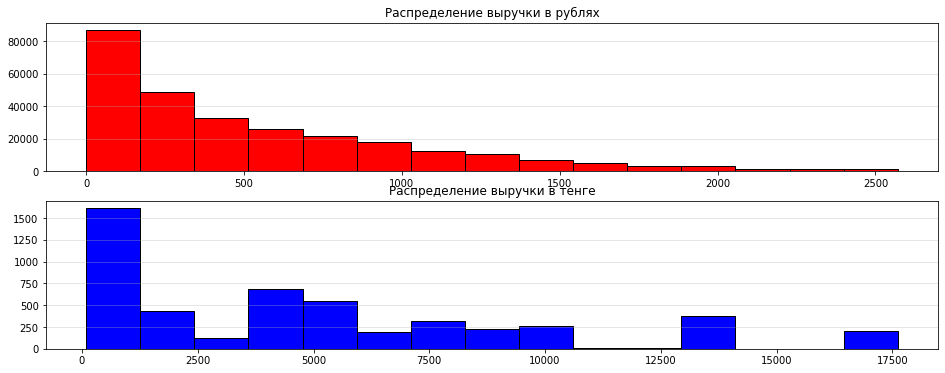

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6))
ax1.hist(df_rub['revenue'],
         bins = 15,
        color='red',
        edgecolor='black')
ax1.set_title('Распределение выручки в рублях')
ax1.grid(axis='y', alpha=0.4)

ax2.hist(df_kzt['revenue'],
         bins=15,
        color='blue',
        edgecolor='black')
ax2.set_title('Распределение выручки в тенге')
ax2.grid(axis='y', alpha=0.4)

Посмотрим статистические показатели по столбцу 'tickets_count'.

In [26]:
display(df['tickets_count'].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.99]))

count    281791.000000
mean          2.744098
std           1.156447
min           1.000000
1%            1.000000
10%           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
99%           6.000000
max          47.000000
Name: tickets_count, dtype: float64

- минимальное значение и 1% равняются 1
- максимальное значение 47 является выбросом.

Отфильтруем датафрейм по 99%.

In [27]:
df = df.loc[df['tickets_count'] <= 6]

Посмотрим на распределение данных:

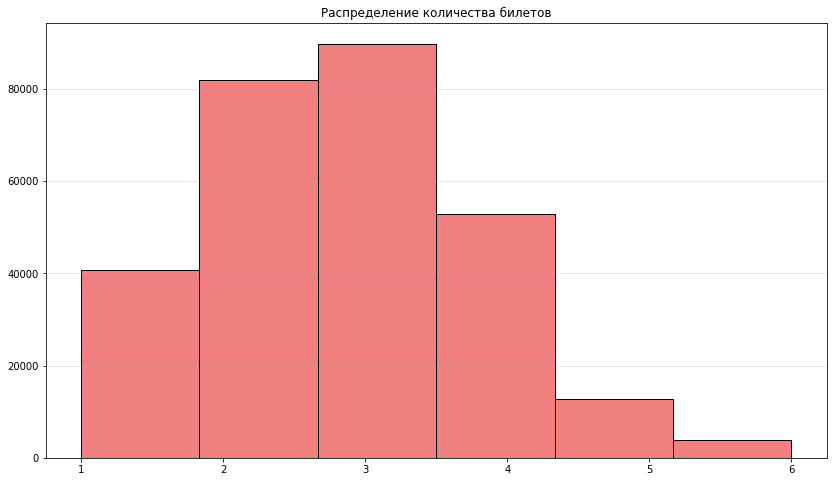

In [28]:
plt.figure(figsize=(14, 8))
plt.hist(df['tickets_count'],
             bins=6,
             color='lightcoral',
             edgecolor='black')
plt.title('Распределение количества билетов')
plt.ylabel('')
plt.grid(axis='y', alpha=0.4)

**Добавим новые столбцы для дальнейшего анализа.**

In [29]:
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)

In [30]:
df['one_ticket_revenue_rub'] = df['revenue_rub']/df['tickets_count']

In [31]:
df['month'] = df['created_dt_msk'].dt.month

In [32]:
def seasons(x):
    if x<3:
        return 'Зима'
    elif x<6:
        return 'Весна'
    elif x<9:
        return 'Лето'
    elif x<12:
        return 'Осень'
    else:
        return 'Зима'
df['season'] = df['month'].apply(seasons)

**Удалим лишние столбцы**

In [33]:
df = df.drop(['cdx', 'nominal', 'data', 'cinema_circuit'], axis=1)

**Подведем итоги предобработки данных.**

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 281617 entries, 0 to 43153
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                281617 non-null  object        
 1   user_id                 281617 non-null  object        
 2   created_dt_msk          281617 non-null  datetime64[ns]
 3   created_ts_msk          281617 non-null  datetime64[ns]
 4   event_id                281617 non-null  object        
 5   age_limit               281617 non-null  int8          
 6   currency_code           281617 non-null  object        
 7   device_type_canonical   281617 non-null  object        
 8   revenue                 281617 non-null  float32       
 9   service_name            281617 non-null  object        
 10  tickets_count           281617 non-null  int8          
 11  total                   281617 non-null  float32       
 12  days_since_prev         260239 

В результате предобработки данных были удалены пропуски и дубликаты. В итоговом датафрейме содержится 281617 строк и 28 столбцов. Изменен тип данных в столбцах 'created_dt_msk', 'created_ts_msk', 'order_id', 'event_id', 'city_id', 'venue_id'. Изучены категориальные данные. Проанализировано распределение количественных данных и проведена фильтрация от выбросов. Созданы новые столбцы: 'revenue_rub' - выручка в рублях с учетом курса валюты, 'one_ticket_revenue_rub' - выручка с одного билета, 'month' - месяц оформления заказа, 'season' - сезон оформления заказа.

# Шаг 3. Исследовательский анализ данных

## Анализ распределения заказов по сегментам и их сезонные изменения

Анализ дашборда показал, что в данных наблюдается сезонность — осенью количество заказов увеличивается. Необходимо изучить изменение пользовательской активности или пользовательского интереса в связи с сезонностью. Проанализировать динамику по таким разрезам: тип мероприятия, тип устройства, категория мероприятий по возрастному рейтингу.

**Для каждого месяца найдем количество заказов**

In [35]:
df_month = df.groupby('month').agg(count_ord=('order_id', 'count')).reset_index()
display(df_month)

,month,count_ord
0,6,32881
1,7,37852
2,8,43121
3,9,68826
4,10,98937


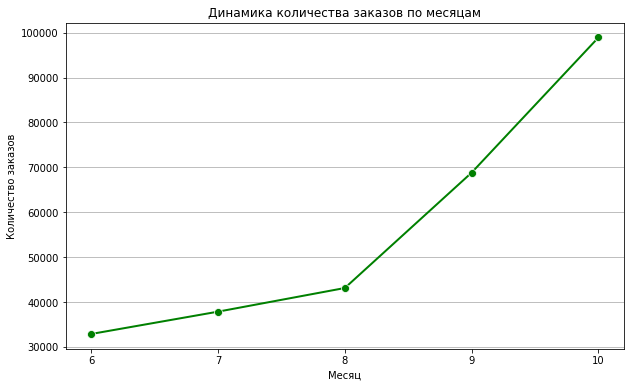

In [36]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df_month,
            x='month',
            y='count_ord',
            marker='o',
             markersize=8,
            linewidth=2,
            color='green')
plt.title('Динамика количества заказов по месяцам')
plt.xlabel('Месяц')
plt.xticks(df_month['month'])
plt.ylabel('Количество заказов')
plt.grid(axis='y')

Как видно на графике, количество заказов стремительно возрастает к осени. Однако такую динамику еще нельзя назвать цикличностью, так как мы изучили данные только за один год. Повышение количества заказов может быть вызвано разными факторами, например: маркетинговыми кампаниями, акциями и скидками. 

**Для осеннего и летнего периодов сравним распределение заказов билетов.**

По типу мероприятия:

In [37]:
df_seasons = df.groupby(['season', 'event_type_main']).agg(count_ord=('order_id', 'count')).reset_index()
df_seasons['share, %'] = df_seasons.groupby('season')['count_ord'].transform(lambda x: x/x.sum()*100)
display(df_seasons.head(5))

,season,event_type_main,count_ord,"share, %"
0,Лето,выставки,2407,2.114111
1,Лето,другое,28399,24.943348
2,Лето,концерты,49980,43.898326
3,Лето,спорт,2759,2.423279
4,Лето,стендап,6346,5.573805


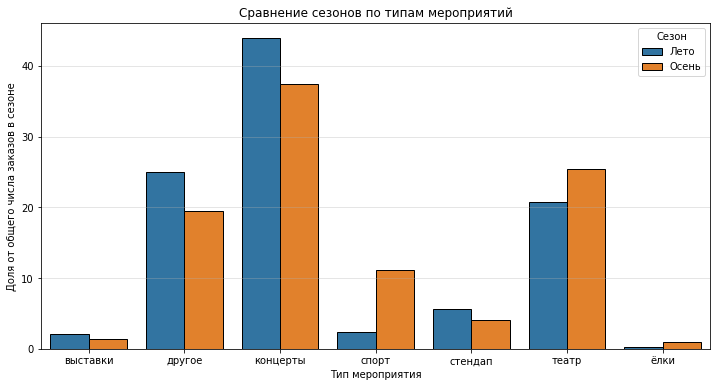

In [38]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_seasons,
           x='event_type_main',
           y='share, %',
           hue='season',
           edgecolor='black')
plt.title('Сравнение сезонов по типам мероприятий')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля от общего числа заказов в сезоне')
plt.legend(title='Сезон')
plt.grid(axis='y', alpha=0.4)

Исходя из диаграммы, летом наибольшую долю заказов имела категория 'концерты', что отражает высокий спрос на развлекательные мероприятия в теплый сезон, а наименьшую 'ёлки' - логично, ведь летом такие мероприятия проводят крайне редко. Сравнивая лето и осень, можно сказать, что к осени доля концертов снижается. Заметно возрастает спрос на категории 'театр' и 'спорт', ведь с наступлением холодов люди все чаще выбирают мероприятия закрытых форматов.

По типу устройства:

In [39]:
df_device = df.groupby(['season', 'device_type_canonical']).agg(count_ord=('order_id', 'count')).reset_index()
df_device['share, %'] = df_device.groupby('season')['count_ord'].transform(lambda x: x/x.sum()*100)
display(df_device)

,season,device_type_canonical,count_ord,"share, %"
0,Лето,desktop,21746,19.09990
1,Лето,mobile,92108,80.90010
2,Осень,desktop,34185,20.37696
3,Осень,mobile,133578,79.62304


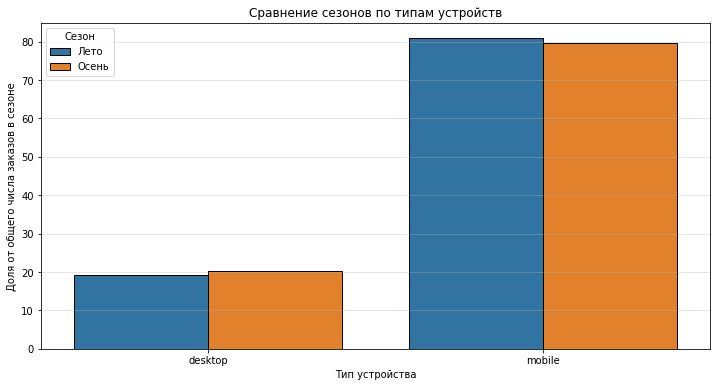

In [40]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_device,
           x='device_type_canonical',
           y='share, %',
           hue='season',
           edgecolor='black')
plt.title('Сравнение сезонов по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Доля от общего числа заказов в сезоне')
plt.legend(title='Сезон')
plt.grid(axis='y', alpha=0.4)

Исходя из диаграммы можно сказать, что распределение заказов по типам устройств имеет незначитильное изменение в сравнении сезонов. Летом, так же как и осенью мобильные телефоны преобладают над компьютерами, однако осенью около 1% заказов переместилось на компьютеры. Такое изменение логично, ведь с наступлением холодов люди чаще проводят время дома за компьютером.

По возрастному рейтингу:

In [41]:
df_age = df.groupby(['season', 'age_limit']).agg(count_ord=('order_id', 'count')).reset_index()
df_age['share, %'] = df_age.groupby('season')['count_ord'].transform(lambda x: x/x.sum()*100)
display(df_age.head(5))

,season,age_limit,count_ord,"share, %"
0,Лето,0,20644,18.131994
1,Лето,6,20874,18.334007
2,Лето,12,24203,21.257927
3,Лето,16,32370,28.431149
4,Лето,18,15763,13.844924


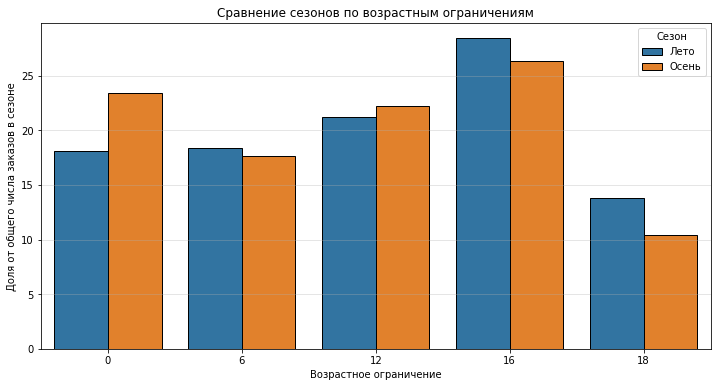

In [42]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_age,
           x='age_limit',
           y='share, %',
           hue='season',
           edgecolor='black')
plt.title('Сравнение сезонов по возрастным ограничениям')
plt.xlabel('Возрастное ограничение')
plt.ylabel('Доля от общего числа заказов в сезоне')
plt.legend(title='Сезон')
plt.grid(axis='y', alpha=0.4)

Исходя из диаграммы лидер по доле заказов в обоих сезонах категория '16+', основной спрос приходится на мероприятия для подростков. Категория '18+' ожидаемо имеет минимальную долю в обоих сезонах, так как таких событий обычно немного. Осенью значительно возрастает спрос на мероприятия с ограничением '0+', это может быть связано со стартом учебного года и появляются мероприятия связанные с этим. 

**Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью**

In [43]:
df_rev_tick = df.groupby(['event_type_main', 'season']).agg(mean_rev =('one_ticket_revenue_rub', 'mean')).reset_index()
pivot_rev_tick = df_rev_tick.pivot(index='event_type_main', columns='season', values='mean_rev').reset_index()
pivot_rev_tick['change, %'] = (pivot_rev_tick['Осень']-pivot_rev_tick['Лето'])/pivot_rev_tick['Лето']*100
display(pivot_rev_tick)

season,event_type_main,Лето,Осень,"change, %"
0,выставки,86.744476,91.905090,5.949214
1,другое,88.024765,77.414047,-12.054241
2,концерты,309.569031,268.447815,-13.283375
3,спорт,55.251541,50.263794,-9.027345
4,стендап,218.518112,231.124969,5.769250
5,театр,216.403229,176.098770,-18.624704
6,ёлки,271.436188,229.564209,-15.426085


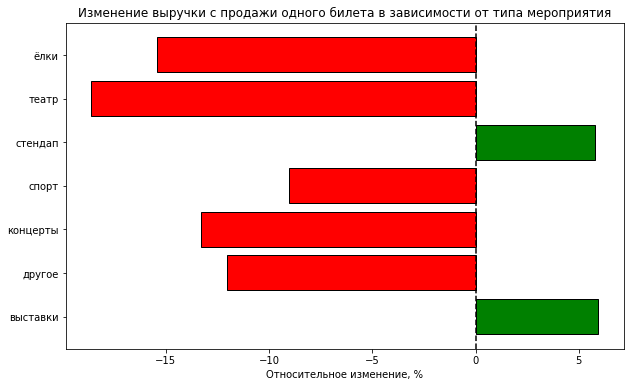

In [44]:
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0
         else'green'
         for x in pivot_rev_tick['change, %']]
plt.barh(pivot_rev_tick['event_type_main'],
        pivot_rev_tick['change, %'],
        color=colors,
        edgecolor='black')
plt.title('Изменение выручки с продажи одного билета в зависимости от типа мероприятия')
plt.xlabel('Относительное изменение, %')
plt.axvline(x=0,
            color='black',
            linestyle='--')

Исходя из графика, можно сделать вывод, что осенью выручка с одного билета выросла в категориях 'выставки' (+5,95%) и 'стендап' (+5,77%). Остальные категории показали сильное снижение выручки с одного билета. Это говорит о смене спроса на разные форматы - летом люди готовы платить больше за масштабные уличные события.

## Анализ осенней активности пользователей

Небходимо изучить активность пользователей осенью 2024 года. Проанализировть динамику изменений по дням и изучить недельную цикличность.

Отфильтруем датафрейм, оставим только 2 осенних месяца.

In [45]:
df_aut = df[df['season'] == 'Осень']

**Проанализируйте динамику изменений по дням.**

In [46]:
df_group_aut = df_aut.groupby('created_dt_msk').agg(count_ord=('order_id', 'count'),
                                                   count_us=('user_id', 'nunique'),
                                                   avg_rev_tick=('one_ticket_revenue_rub', 'mean')).reset_index()
df_group_aut['ord_per_us'] = df_group_aut['count_ord']/df_group_aut['count_us']
df_group_aut['dow'] = df_group_aut['created_dt_msk'].dt.weekday
display(df_group_aut.head(5))

,created_dt_msk,count_ord,count_us,avg_rev_tick,ord_per_us,dow
0,2024-09-01,1312,555,202.437180,2.363964,6
1,2024-09-02,1370,571,190.847824,2.399299,0
2,2024-09-03,5090,776,80.713516,6.559278,1
3,2024-09-04,1757,683,179.598099,2.572474,2
4,2024-09-05,1934,738,190.340302,2.620596,3


Text(0.5, 0, 'Дата')

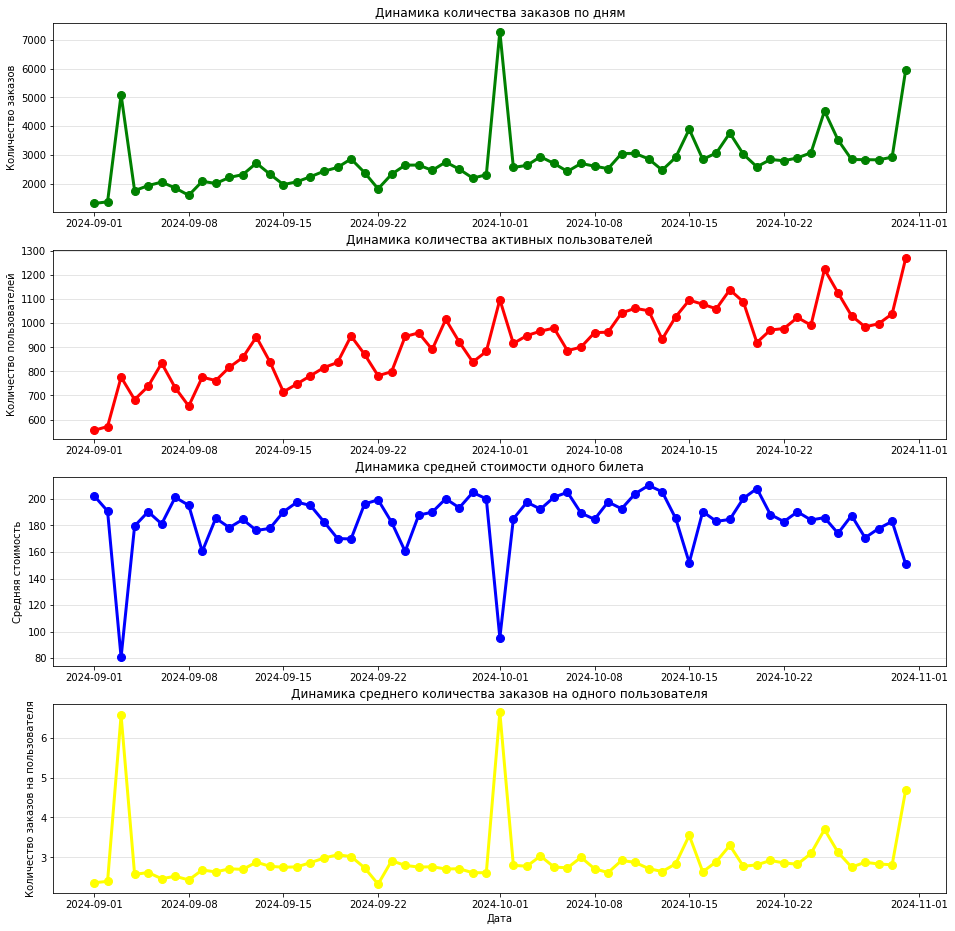

In [47]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
axes[0].plot(df_group_aut['created_dt_msk'],
             df_group_aut['count_ord'],
             marker='o',
             markersize=8,
            linewidth=3,
            color='green')
axes[0].set_title('Динамика количества заказов по дням')
axes[0].set_ylabel('Количество заказов')
axes[0].grid(axis='y', alpha=0.4)

axes[1].plot(df_group_aut['created_dt_msk'],
             df_group_aut['count_us'],
             marker='o',
             markersize=8,
            linewidth=3,
            color='red')
axes[1].set_title('Динамика количества активных пользователей')
axes[1].set_ylabel('Количество пользователей')
axes[1].grid(axis='y', alpha=0.4)

axes[2].plot(df_group_aut['created_dt_msk'],
             df_group_aut['avg_rev_tick'],
             marker='o',
             markersize=8,
            linewidth=3,
            color='blue')
axes[2].set_title('Динамика средней стоимости одного билета')
axes[2].set_ylabel('Средняя стоимость')
axes[2].grid(axis='y', alpha=0.4)

axes[3].plot(df_group_aut['created_dt_msk'],
             df_group_aut['ord_per_us'],
             marker='o',
             markersize=8,
            linewidth=3,
            color='yellow')
axes[3].set_title('Динамика среднего количества заказов на одного пользователя')
axes[3].set_ylabel('Количество заказов на пользователя')
axes[3].grid(axis='y', alpha=0.4)
axes[3].set_xlabel('Дата')

In [48]:
df_dow = df_group_aut.groupby('dow').agg(count_ord=('count_ord', 'mean'),
                                        count_us=('count_us', 'mean')).reset_index()
display(df_dow)

,dow,count_ord,count_us
0,0,2383.555556,851.333333
1,1,3488.777778,932.888889
2,2,2534.222222,921.888889
3,3,3005.444444,959.666667
4,4,3082.500000,1016.500000
5,5,2647.375000,951.500000
6,6,2135.111111,813.111111


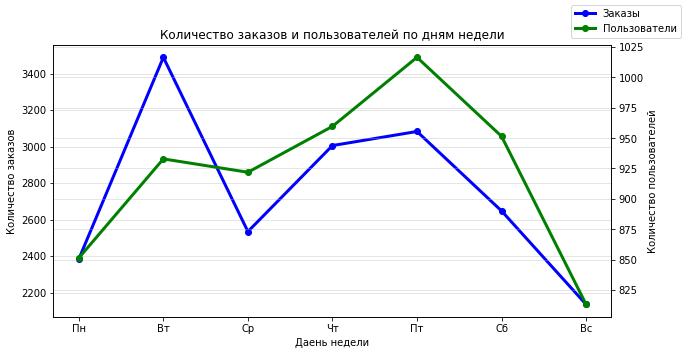

In [49]:
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(day_names,
         df_dow['count_ord'],
         marker='o',
         linewidth=3,
         color='blue',
         label='Заказы')
ax1.set_xlabel('Даень недели')
ax1.set_ylabel('Количество заказов')
ax1.grid(axis='y', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(day_names,
         df_dow['count_us'],
         marker='o',
         linewidth=3,
         color='green',
         label='Пользователи')
ax2.set_xlabel('Даень недели')
ax2.set_ylabel('Количество пользователей')
ax2.grid(axis='y', alpha=0.4)

plt.title('Количество заказов и пользователей по дням недели')
fig.legend()


По итогам анализа активности пользователей можно сделать вывод, что активность неравномерна как внутри недели, так и в течение всей осени. В будние дни активность выше, чем в выходные. Пользователи чаще совершают заказы в рабочие дни, что может быть связано с планированием досуга и рабочими привычками. Пиковые дни активности пользователей - вторник и пятница, по воскресеньям активность мимнимальная.

Необходимо отметить одну интересную особенность. 3 сентября, 1 октября и 31 октября наблюдается резки рост количества заказов и одновременно снижение стоимости одного билета, а также рост среднего количества заказов на одного пользователя. Вероятно в эти дни проводились акции, что привело к повышению активности пользователей.

## Популярные события и партнёры

Необходимо посмотреть, как события распределены по регионам и партнёрам. Это позволит выделить ключевые регионы и партнёров, которые вносят наибольший вклад в выручку.

**Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов.**

In [50]:
df_reg = df.groupby('region_name').agg(count_event=('event_id', 'nunique'),
                                      count_ord=('order_id', 'count')).reset_index()
total_events = df_reg['count_event'].sum()
total_orders = df_reg['count_ord'].sum()
df_reg['share_event, %'] = df_reg['count_event']/total_events * 100
df_reg['share_ord, %'] = df_reg['count_ord']/total_orders * 100
df_reg = df_reg.sort_values('share_event, %', ascending=False)
display(df_reg.head(5))

,region_name,count_event,count_ord,"share_event, %","share_ord, %"
23,Каменевский регион,5792,85374,26.328469,30.315641
60,Североярская область,3774,43473,17.155325,15.436923
77,Широковская область,1217,16082,5.532070,5.710593
57,Светополянский округ,1059,7462,4.813855,2.649698
52,Речиновская область,701,6264,3.186508,2.224298


Выделим топ-10 регионов по количеству проведенных мероприятий.

In [51]:
df_10_reg = df_reg.head(10)
display(df_10_reg)

,region_name,count_event,count_ord,"share_event, %","share_ord, %"
23,Каменевский регион,5792,85374,26.328469,30.315641
60,Североярская область,3774,43473,17.155325,15.436923
77,Широковская область,1217,16082,5.532070,5.710593
57,Светополянский округ,1059,7462,4.813855,2.649698
52,Речиновская область,701,6264,3.186508,2.224298
74,Травяная область,667,4719,3.031956,1.675680
11,Горицветская область,551,5152,2.504659,1.829435
61,Серебринская область,541,5586,2.459203,1.983545
78,Яблоневская область,534,6119,2.427383,2.172809
69,Тепляковская область,528,4383,2.400109,1.556369


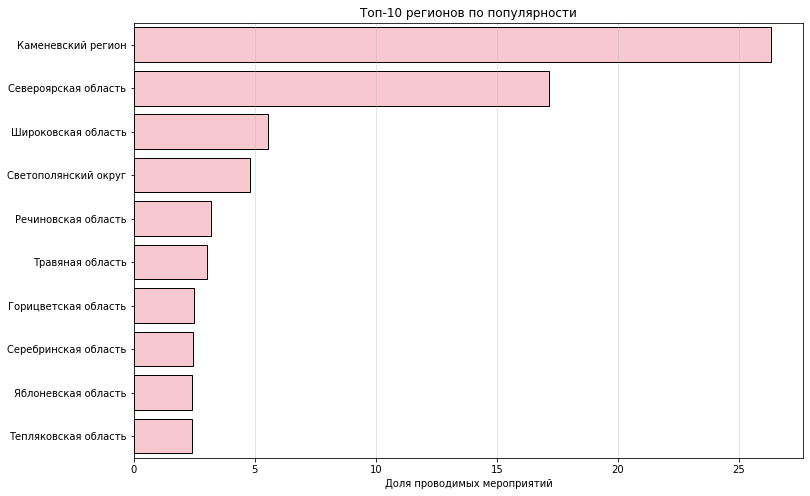

In [52]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df_10_reg,
            y='region_name',
            x='share_event, %',
           color='pink',
           edgecolor='black')
plt.title('Топ-10 регионов по популярности')
plt.xlabel('Доля проводимых мероприятий')
plt.ylabel('')
plt.grid(axis='x', alpha=0.4)

**Посмотрим количество площадок для проведения мероприятий по регионам**

In [53]:
df_ven = df.groupby('region_name').agg(count_venue=('venue_name', 'nunique')).reset_index()
df_ven = df_ven.sort_values('count_venue', ascending=False).head(5)
display(df_ven)

,region_name,count_venue
23,Каменевский регион,724
60,Североярская область,478
57,Светополянский округ,175
77,Широковская область,172
69,Тепляковская область,111


**Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов.**

In [54]:
df_service = df.groupby('service_name').agg(count_event=('event_id', 'nunique'),
                                            count_ord=('order_id', 'count'),
                                           sum_revenue=('revenue_rub', 'sum')).reset_index()
total_events = df_service['count_event'].sum()
total_orders = df_service['count_ord'].sum()
total_revenue = df_service['sum_revenue'].sum()
df_service['share_event, %'] = df_service['count_event']/total_events * 100
df_service['share_ord, %'] = df_service['count_ord']/total_orders * 100
df_service['share_rev, %'] = df_service['sum_revenue']/total_revenue * 100
df_service = df_service.sort_values('share_rev, %', ascending=False).head(10)
display(df_service)

,service_name,count_event,count_ord,sum_revenue,"share_event, %","share_ord, %","share_rev, %"
3,Билеты без проблем,4014,57715,24195422.0,16.707596,20.494146,16.228302
24,Мой билет,1293,34375,22015730.0,5.381894,12.206294,14.766343
25,Облачко,2335,26402,18588614.0,9.719043,9.375144,12.467716
21,Лови билет!,4813,40500,16673066.0,20.033299,14.381234,11.182923
8,Весь в билетах,855,16424,16532347.0,3.558793,5.832034,11.088540
5,Билеты в руки,3486,39792,13191315.0,14.509886,14.129829,8.847651
19,Край билетов,252,6108,6403469.0,1.048907,2.168903,4.294921
26,Прачечная,1026,10222,4746810.5,4.270552,3.629752,3.183771
13,Дом культуры,272,4412,4358656.0,1.132154,1.566667,2.923429
35,Яблоко,714,5004,3868337.0,2.971904,1.776881,2.594563


Выделим топ-10 операторов по выручке.

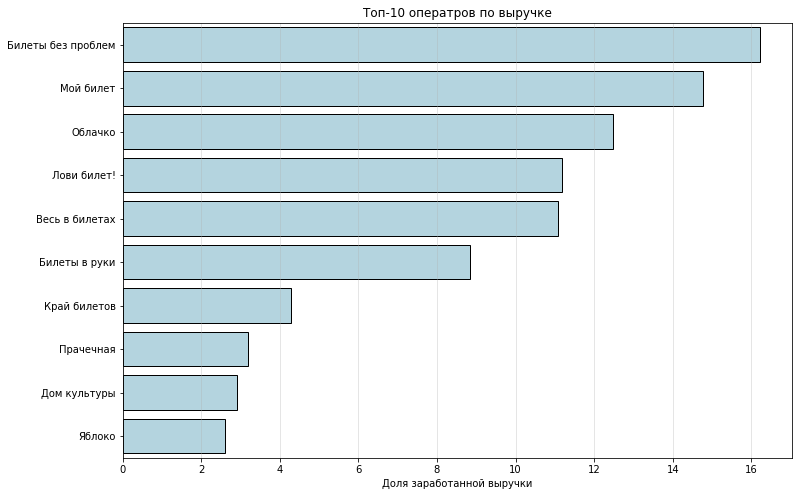

In [55]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df_service,
            y='service_name',
            x='share_rev, %',
           color='lightblue',
           edgecolor='black')
plt.title('Топ-10 оператров по выручке')
plt.xlabel('Доля заработанной выручки')
plt.ylabel('')
plt.grid(axis='x', alpha=0.4)

Исходя из проведенного анализа, можно сказать, что Каменевский регион является лиидером с большим отрывом как по доле проведенных мероприятий (более 26% от общего количества), так и по доле совершенных заказов (более 30% от общего количества). Североярская область на втором месте проводит более 17% мероприятий и около 15% совершенных заказов. Остальные регионы имеют доли мероприятий и заказов менее 5%. Такое распределение может быть обосновано тем, что Каменевский регион и Североярская область имеют наибольшее население, соответственно наибольшее количество площадок для проведения мероприятий. 

Анализ билетных партнеров показал лидера по доле принесенной выручки - 'Билеты без проблем', этот оператор принес около 16% выручки, а также около 20% совершенных заказов. с небольшим отрывом в пределах 5% следуют опреаторы: 'Мой билет', 'Облачко', 'Лови билет!' и 'Весь в билетах'. Оператор 'Лови билет!' при этом занимает 1 место по доле проведенных мероприятий.

# Шаг 4. Статистический анализ данных

1. Необходимо проверить гипотезу: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

Проверим ее используя одностороннюю проверку гипотезы с двумя выборками:

- **Нулевая гипотеза**    𝐻0:𝜇Мобильные<=𝜇Компьютеры    - Среднее количество заказов на одного пользователя мобильного приложения не выше по сравнению с пользователями стационарных устройств
- **Альтернативная гипотеза**     𝐻1:𝜇Мобильные>𝜇Компьютеры    - Среднее количество заказов на одного пользователя мобильного приложения выше и это различие статистически значимо.

Изучим группы по устройствам.

In [56]:
df_us_dev = df_aut.groupby(['user_id', 'device_type_canonical']).agg(order_count=('order_id', 'count')).reset_index()
display(df_us_dev.head(5))

,user_id,device_type_canonical,order_count
0,0005ca5e93f2cf4,mobile,1
1,000898990054619,mobile,2
2,000a55a418c128c,mobile,2
3,001e7037d013f0f,mobile,2
4,00245c702bc343e,mobile,2


Необходимо дополнительно проверить пересечение выборок.

In [57]:
mob = df_us_dev[df_us_dev['device_type_canonical'] == 'mobile']['user_id']
desk = df_us_dev[df_us_dev['device_type_canonical'] == 'desktop']['user_id']

intersection = len(set(mob) & set(desk))
print(intersection)

3234


Более 3200 пользователей делали заказы как с мобильного так и со стационарного устройства. При такой ситуации есть несколько вариантов решения проблемы, чтобы сделать выборки независымимы. Было принято решение относить пользователя к тому устройству, с которого было сделано более 50% заказов или единственный заказ. Если заказов поровну между устройствами, возьмем mobile.

In [58]:
total_orders = df_us_dev.groupby('user_id').agg(total_ord=('order_count', 'sum')).reset_index()
display(total_orders.head(5))

,user_id,total_ord
0,0005ca5e93f2cf4,1
1,000898990054619,2
2,000a55a418c128c,2
3,001e7037d013f0f,2
4,00245c702bc343e,2


In [59]:
df_us_dev = df_us_dev.merge(total_orders, on='user_id')
df_us_dev['share'] = df_us_dev['order_count']/df_us_dev['total_ord']
display(df_us_dev.head(5))

,user_id,device_type_canonical,order_count,total_ord,share
0,0005ca5e93f2cf4,mobile,1,1,1.0
1,000898990054619,mobile,2,2,1.0
2,000a55a418c128c,mobile,2,2,1.0
3,001e7037d013f0f,mobile,2,2,1.0
4,00245c702bc343e,mobile,2,2,1.0


In [60]:
good_users = df_us_dev[df_us_dev['share'] > 0.5]
good_users = good_users.sort_values('share', ascending=False)
good_users = good_users.drop_duplicates('user_id', keep='first')
display(good_users.head(5))

,user_id,device_type_canonical,order_count,total_ord,share
0,0005ca5e93f2cf4,mobile,1,1,1.0
11992,a2175b9f767fc27,mobile,6,6,1.0
11998,a21f98a21add95a,mobile,2,2,1.0
11999,a2205abedf425c2,mobile,1,1,1.0
12000,a2254749c79f2dc,desktop,1,1,1.0


 Составим итоговые выборки по отфильтрованным данными и их среднее количество заказов на одного пользователя.

In [61]:
df_mob_desk = good_users.groupby('device_type_canonical').agg(count_users=('user_id', 'count'),
                                                             total_orders=('order_count', 'sum')).reset_index()
df_mob_desk['avg_orders'] = df_mob_desk['total_orders']/df_mob_desk['count_users']
display(df_mob_desk)

,device_type_canonical,count_users,total_orders,avg_orders
0,desktop,2119,8103,3.823974
1,mobile,13163,130937,9.947352


На первый взгляд среднее количество заказов выше у мобильных устройств, однако нельзя делать выводы без статистического теста. Для этого необходимо проанализировать размеры выборок.

In [62]:
count_mob = df_mob_desk[df_mob_desk['device_type_canonical']=='mobile']['count_users'].values[0]
count_desk = df_mob_desk[df_mob_desk['device_type_canonical']=='desktop']['count_users'].values[0]
percent_diff = abs(count_mob-count_desk)/count_mob*100
print(f"Процентная разница между количеством пользователей по устройствам: {percent_diff:.2f}%")

Процентная разница между количеством пользователей по устройствам: 83.90%


Группы по устройствам имеют серьезное различие по количеству пользователей. Это может повлиять на результаты статистического теста при проверке гипотезы. Важно правильно выбрать подходящий тип статистического теста. Для этого необходимо рассмотреть распределения данных.

In [63]:
group_mob = good_users[good_users['device_type_canonical']=='mobile']['order_count']
group_desk = good_users[good_users['device_type_canonical']=='desktop']['order_count']

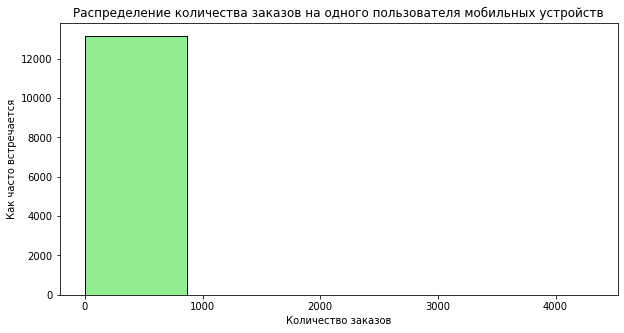

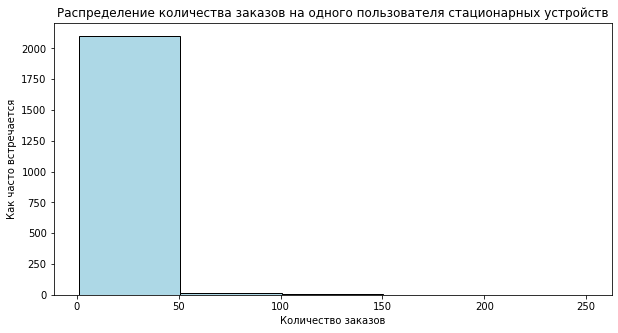

In [64]:
plt.figure(figsize=(10, 5))
plt.hist(group_mob,
         color='lightgreen',
         bins=5,
         edgecolor='black')
plt.xlabel('Количество заказов')
plt.ylabel('Как часто встречается')
plt.title('Распределение количества заказов на одного пользователя мобильных устройств')
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(group_desk,
         color='lightblue',
         bins=5,
         edgecolor='black')
plt.xlabel('Количество заказов')
plt.ylabel('Как часто встречается')
plt.title('Распределение количества заказов на одного пользователя стационарных устройств')
plt.show()

В обеих группах распределения не похожи на нормальные, имеются ярковыраженные правые хвосты.

Исходя из рассмотренных особенностей: разные размеры выборок, распределения далекие от нормального - было принято решение использовать **тест Манна-Уитни** для проверки гипотезы.

In [65]:
alpha = 0.05
mw_test = mannwhitneyu(
    group_mob,
    group_desk,
    alternative='greater'
)

if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группе мобильных устройств не выше чем в группе стационарных.')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Распределения метрики в группе мобильных устройств выше чем в группе стационарных.')

pvalue=2.821728070572796e-28 < 0.05
Нулевая гипотеза не находит подтверждения! Распределения метрики в группе мобильных устройств выше чем в группе стационарных.


При проверке гипотезы мы работали с количественными данными с распределением не близким к нормальному. Выборки можно считать независимыми, так как заказы разных пользователей не влияют друг на друга и один пользователь принадлежит только одной группе. Для проверки гипотезы был выбран тест Манна-Уитни с уровнем статистической значимости 5%.

По результатам теста p-value составил ~ < 0.05. Нулевая гипотеза не находит подтверждение. Среднее количество заказов на одного пользователя мобильного приложения выше чем у стационарных устройств.
Результаты можно назвать ожидаемыми, ведь в целом пользователей мобильных устройств больше, так людям удобнее и привычнее выполнять заказы.

2. Проверим вторую гипотезу. Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

- **Нулевая гипотеза**    𝐻0:𝜇Мобильные<=𝜇Компьютеры    - Среднее время между заказами пользователей мобильных приложений не выше по сравнению с пользователями стационарных устройств
- **Альтернативная гипотеза**     𝐻1:𝜇Мобильные>𝜇Компьютеры    - Среднее время между заказами пользователей мобильных приложений выше и это различие статистически значимо.

Изучим группы по устройствам

In [66]:
df_days_dev = df_aut.groupby('user_id').agg(avg_days=('days_since_prev', 'mean')).reset_index()
display(df_days_dev.head(5))

,user_id,avg_days
0,0005ca5e93f2cf4,75.0
1,000898990054619,51.0
2,000a55a418c128c,16.0
3,001e7037d013f0f,43.5
4,00245c702bc343e,27.5


Так как столбец 'days_since_prev' заполняется только в случае наличия второго заказа, у нас появляются пропуски, их необходимо удалить.

In [67]:
df_days_dev = df_days_dev.dropna(subset=['avg_days'])

Ранее мы отфильтровали данные, чтобы избежать пересечение выборок. Используем их для дальнейшего анализа.

In [68]:
df_days = good_users.merge(df_days_dev, on='user_id')
df_days = df_days.drop(['order_count', 'total_ord', 'share'], axis=1)
display(df_days.head(5))

,user_id,device_type_canonical,avg_days
0,0005ca5e93f2cf4,mobile,75.000000
1,a2175b9f767fc27,mobile,15.166667
2,a21f98a21add95a,mobile,68.000000
3,a2205abedf425c2,mobile,94.000000
4,a2256f35162323d,mobile,15.333333


In [69]:
mob = df_days[df_days['device_type_canonical'] == 'mobile']['user_id']
desk = df_days[df_days['device_type_canonical'] == 'desktop']['user_id']

intersection = len(set(mob) & set(desk))
print(intersection)

0


Составим итоговые выборки по отфильтрованным данными и их среднее время между заказами.

In [70]:
df_mob_desk = df_days.groupby('device_type_canonical').agg(avg_days=('avg_days', 'mean'),
                                                            users_count=('user_id', 'count')).reset_index()
display(df_mob_desk)

,device_type_canonical,avg_days,users_count
0,desktop,23.723823,1395
1,mobile,20.596807,9315


На первый взгляд среднее время между заказами выше у стационарных устройств, однако нельзя делать выводы без статистического теста. Для этого необходимо проанализировать размеры выборок.

In [71]:
count_mob = df_mob_desk[df_mob_desk['device_type_canonical']=='mobile']['users_count'].values[0]
count_desk = df_mob_desk[df_mob_desk['device_type_canonical']=='desktop']['users_count'].values[0]
percent_diff = abs(count_mob-count_desk)/count_mob*100
print(f"Процентная разница между количеством пользователей по устройствам: {percent_diff:.2f}%")

Процентная разница между количеством пользователей по устройствам: 85.02%


Группы по устройствам имеют серьезное различие по количеству пользователей. Это может повлиять на результаты статистического теста при проверке гипотезы. Важно правильно выбрать подходящий тип статистического теста. Для этого необходимо рассмотреть распределения данных.

In [72]:
group_mob = df_days[df_days['device_type_canonical']=='mobile']['avg_days']
group_desk = df_days[df_days['device_type_canonical']=='desktop']['avg_days']

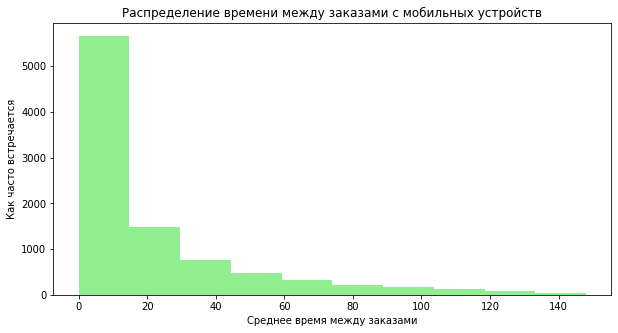

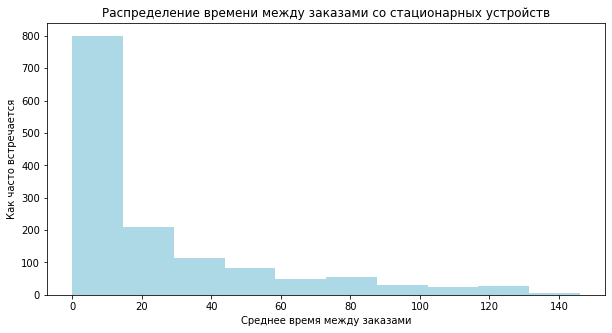

In [73]:
plt.figure(figsize=(10, 5))
plt.hist(group_mob, color='lightgreen', bins=10)
plt.xlabel('Среднее время между заказами')
plt.ylabel('Как часто встречается')
plt.title('Распределение времени между заказами с мобильных устройств')
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(group_desk, color='lightblue', bins=10)
plt.xlabel('Среднее время между заказами')
plt.ylabel('Как часто встречается')
plt.title('Распределение времени между заказами со стационарных устройств')
plt.show()

В обеих группах распределения не похожи на нормальные, имеются ярковыраженные правые хвосты.

Исходя из рассмотренных особенностей: разные размеры выборок, распределения далекие от нормального - было принято решение использовать **тест Манна-Уитни** для проверки гипотезы.

In [74]:
alpha = 0.05
mw_test = mannwhitneyu(
    group_mob,
    group_desk,
    alternative='greater'
)

if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группе мобильных устройств не выше чем в группе стационарных.')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Распределения метрики в группе мобильных устройств выше чем в группе стационарных.')

pvalue=0.684977374768207 > 0.05
Нулевая гипотеза находит подтверждение! Распределения метрики в группе мобильных устройств не выше чем в группе стационарных.


Для проверки гипотезы был выбран тест Манна-Уитни с уровнем статистической значимости 5%.

По результатам теста p-value составил ~0.999 > 0.05. Нулевая гипотеза находит подтверждение. Среднее время между заказами пользователей мобильных приложений не выше чем у стационарных устройств.
Можно предположить, что устройство с которого пользователи оформляют заказы не влияет на потребность людей в услугах сервиса.

# Шаг 5. Общий вывод и рекомендации

Мы работали с данными о заказах и событиях сервиса Яндекс Афиша. В процессе работы над проектом мы познакомились с данными, провели предобработку, удалили пропуски и дубликаты.

В ходе анализа популярных мероприятий, было выявлено, что в обоих сезонах (лето и зима) лидером по количеству заказов стали концерты, на них приходится ~40% всех заказов. Наименьшая доля заказов (менее 1%) приходится на 'ёлки', так как в эти сезоны такие мероприятия редко проводятся и не пользуются спросом. 
Средний чек осенью снизился на все категории мероприятий, кроме 'стендапы'  и 'выставки' Наибольшее снижение среднего чека произошло в категории 'театры' -18,6%. 
По итогам анализа активности пользователей был сделан вывод, что активность неравномерна как внутри недели, так и в течение всей осени. В будние дни активность выше, чем в выходные. Пиковые дни активности пользователей - вторник и пятница, по воскресеньям активность минимальная. Выявлено, что 3 сентября, 1 октября и 31 октября наблюдается резки рост количества заказов и одновременно снижение стоимости одного билета, а также рост среднего количества заказов на одного пользователя. Вероятно в эти дни проводились акции, что привело к повышению активности пользователей.

Исходя из проведенного анализа регионов и партнеров, можно сказать, что Каменевский регион является лидером как по доле проведенных мероприятий (более 26% от общего количества), так и по доле совершенных заказов (более 30% от общего количества). Североярская область на втором месте проводит более 17% мероприятий и около 15% совершенных заказов. Каменевский регион и Североярская область имеют наибольшее количество площадок для проведения мероприятий.
Анализ билетных партнеров показал лидера по доле принесенной выручки - 'Билеты без проблем', этот оператор принес около 16% выручки, а также около 20% совершенных заказов. Оператор 'Лови билет!' при этом занимает 1 место по доле проведенных мероприятий.

При проверке гипотез и подготовке данных было выявлено, что более 3200 пользователей делали заказы как с мобильного так и со стационарного устройства. Определив основное устройство каждого пользователя, были проведены 2 теста Манна-Уитни.
Гипотеза о том, что среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств подтвердилась, так как нулевая гипотеза была отвергнута. Такой результат ожидаем, ведь в наше время люди чаще пользуются мобильными телефонами и они всегда под рукой. 
Гипотеза о том, что Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств не нашла подтверждения, так как нулевая гипотеза не была отвергнута. Независимо от устройства пользователи возвращаются в сервис с одинаковой периодичностью.

#### Рекомендации:
- Необходимо инвестировать в мобильное приложение, чтобы повышать активность пользователей этих устройств. А также провести анализ десктопной версии, чтобы выяснить причины низкой активности пользователей этих устройств.
- Организовать рассылку push-уведомлений для пользователей мобильной версии и писем для пользователей десктопной версии о ближайших событиях, исходя из предпочтений пользователя.
- Сделать акцент на регионах отстающих от лидеров, предлагать специальные акции/скидки на мероприятия в этих регионах.
- Осенью делать акцент на мероприятиях спрос на которые возрастает (театры, спротивные мероприятия), но и не упускать категории, у которых спрос снижается, предлагать на них акции/скидки.